# NLP-Based Quality Feedback Analyzer
## Week 1: Preprocessing & Exploratory Analysis

This notebook performs the initial setup, exploratory data analysis (EDA), text cleaning, and preliminary visualization for the Amazon Product Reviews dataset.

### Tasks Completed:
1. Load raw dataset and explore dimensions, data types, nulls, and distributions.
2. Filter the dataset to the 10,000 most relevant/representative unique reviews (sorted by helpfulness, dropping duplicate review texts).
3. Build and apply a sequential text cleaning pipeline:
   - Lowercasing
   - Punctuation & special character removal
   - Tokenization
   - Stopwords removal (NLTK)
   - Lemmatization (NLTK WordNetLemmatizer)
4. Export preprocessed data to `data/processed/reviews_cleaned.csv`.
5. Generate and compare word clouds for 1-star and 5-star reviews.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import ssl

# Bypass SSL verification for NLTK downloads if needed
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("Libraries imported and NLTK resources downloaded successfully.")

Libraries imported and NLTK resources downloaded successfully.


### 1. Loading and Exploring the Raw Data

We load the raw Amazon Product Reviews dataset from `data/raw/Reviews.csv`.

In [2]:
# Load the CSV
raw_csv_path = "../data/raw/Reviews.csv"
df_raw = pd.read_csv(raw_csv_path)

# Print basic dataset info
print(f"Dataset shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\nColumns and data types:")
print(df_raw.dtypes)

print("\nNull values count:")
print(df_raw.isnull().sum())

print("\nRating (Score) Distribution:")
score_counts = df_raw['Score'].value_counts().sort_index()
for score, count in score_counts.items():
    print(f"  {score}-star: {count:,} ({count/len(df_raw)*100:.2f}%)")

print("\nFirst 3 sample rows:")
df_raw.head(3)

Dataset shape: 568454 rows, 10 columns

Columns and data types:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Null values count:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Rating (Score) Distribution:
  1-star: 52,268 (9.19%)
  2-star: 29,769 (5.24%)
  3-star: 42,640 (7.50%)
  4-star: 80,655 (14.19%)
  5-star: 363,122 (63.88%)

First 3 sample rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


### 2. Identifying Columns and Filtering

We identify:
- **Review text column**: `Text`
- **Rating column**: `Score` (ranges from 1 to 5)

Since the dataset is large (~568k reviews) and lacks a `Category` column, we filter it down to the **10,000 most relevant/representative unique reviews** by first sorting in descending order of `HelpfulnessNumerator` (number of users who marked the review as helpful) and then dropping duplicate reviews based on the text contents, keeping the most helpful duplicate.

In [3]:
# Filter the top 10,000 most representative unique reviews
df_sorted = df_raw.sort_values(by='HelpfulnessNumerator', ascending=False)
df_unique = df_sorted.drop_duplicates(subset='Text', keep='first')
df_filtered = df_unique.head(10000).copy()

print(f"Filtered dataset shape: {df_filtered.shape}")
print("\nFiltered Score Distribution:")
filtered_counts = df_filtered['Score'].value_counts().sort_index()
for score, count in filtered_counts.items():
    print(f"  {score}-star: {count:,} ({count/len(df_filtered)*100:.2f}%)")

Filtered dataset shape: (10000, 10)

Filtered Score Distribution:
  1-star: 1,659 (16.59%)
  2-star: 565 (5.65%)
  3-star: 705 (7.05%)
  4-star: 1,043 (10.43%)
  5-star: 6,028 (60.28%)


### 3. Text Preprocessing Pipeline

We build a text cleaning pipeline applied in this exact order:
1. **Lowercase**: Convert all text to lowercase.
2. **Remove punctuation/special characters**: Use regular expressions to strip out punctuation, numbers, and formatting.
3. **Tokenize**: Break text into individual words/tokens.
4. **Remove Stopwords**: Filter out common English stopwords (e.g. 'the', 'is', 'and') using NLTK.
5. **Lemmatize**: Convert words to their base dictionary form (lemma) using NLTK's `WordNetLemmatizer`.

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_review_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text_lower = text.lower()
    
    # 2. Remove punctuation and special characters (keeping only letters and spaces)
    text_cleaned = re.sub(r'[^a-z\s]', '', text_lower)
    
    # 3. Tokenize
    tokens = word_tokenize(text_cleaned)
    
    # 4. Remove stopwords
    tokens_no_stop = [w for w in tokens if w not in stop_words]
    
    # 5. Lemmatize
    tokens_lemmatized = [lemmatizer.lemmatize(w) for w in tokens_no_stop]
    
    # Return as space-separated clean text string
    return " ".join(tokens_lemmatized)

# Apply pipeline - keep original raw 'Text' and add 'cleaned_text' as a separate column
df_filtered['cleaned_text'] = df_filtered['Text'].apply(clean_review_text)

# Inspect a few random reviews to verify preprocessing quality
print("Verification of Preprocessing Pipeline (Original vs Cleaned):")
df_comparison = df_filtered[['Score', 'Text', 'cleaned_text']].head(5)
for index, row in df_comparison.iterrows():
    print(f"\nRating: {row['Score']}-Star")
    print(f"Original: {row['Text'][:150]}...")
    print(f"Cleaned : {row['cleaned_text'][:150]}...")

Verification of Preprocessing Pipeline (Original vs Cleaned):

Rating: 5-Star
Original: see update at end of review<br /><br />******************<br /><br />I was lamenting about only having frech lettuce, herbs, chives, and tomatoes from...
Cleaned : see update end reviewbr br br br lamenting frech lettuce herb chive tomato may garden long fallwinterspring part year refrigerated stuff grocery store...

Rating: 3-Star
Original: I ordered one of these Fresh "Whole" Rabbits, but when it arrived its head, fur and insides were missing.  Not exactly whole, I'd say!  Maybe it was j...
Cleaned : ordered one fresh whole rabbit arrived head fur inside missing exactly whole id say maybe damaged shipping wont buying another one mean without long e...

Rating: 5-Star
Original: I purchased a burrito from a small shop a few blocks from home. I was unimpressed with their habanero "hot" salsa. Eager to kick it up a notch, I reac...
Cleaned : purchased burrito small shop block home unimpressed habanero

### 4. Saving Processed Dataset

We save the preprocessed dataframe to `data/processed/reviews_cleaned.csv`. We keep the original raw text columns and the new `cleaned_text` column.

In [5]:
# Save the results
processed_csv_path = "../data/processed/reviews_cleaned.csv"
os.makedirs(os.path.dirname(processed_csv_path), exist_ok=True)
df_filtered.to_csv(processed_csv_path, index=False)
print(f"Saved {len(df_filtered)} processed reviews to {processed_csv_path}")

Saved 10000 processed reviews to ../data/processed/reviews_cleaned.csv


### 5. Word Cloud Generation

We generate two word clouds from the `cleaned_text` column using the `wordcloud` library:
1. One from **1-star reviews**
2. One from **5-star reviews**

The word clouds will be saved to `outputs/wordclouds/wordcloud_1star.png` and `outputs/wordclouds/wordcloud_5star.png` and displayed side-by-side.

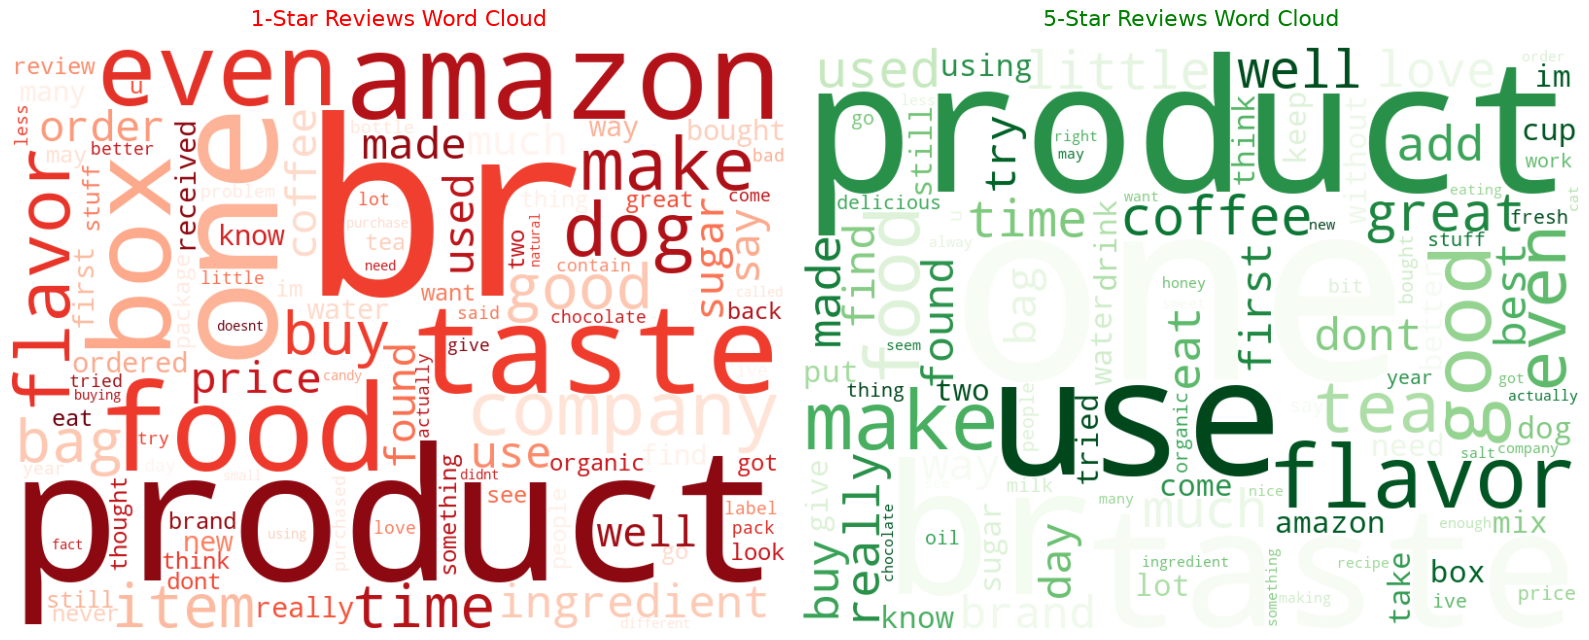

In [6]:
# Filter reviews by score
text_1star = " ".join(df_filtered[df_filtered['Score'] == 1]['cleaned_text'].dropna().astype(str))
text_5star = " ".join(df_filtered[df_filtered['Score'] == 5]['cleaned_text'].dropna().astype(str))

# Create outputs/wordclouds directory
os.makedirs("../outputs/wordclouds", exist_ok=True)

# Generate 1-star wordcloud
wc_1star = WordCloud(width=800, height=600, background_color='white', colormap='Reds', max_words=100).generate(text_1star)
wc_1star.to_file("../outputs/wordclouds/wordcloud_1star.png")

# Generate 5-star wordcloud
wc_5star = WordCloud(width=800, height=600, background_color='white', colormap='Greens', max_words=100).generate(text_5star)
wc_5star.to_file("../outputs/wordclouds/wordcloud_5star.png")

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1-star plot
axes[0].imshow(wc_1star, interpolation='bilinear')
axes[0].set_title('1-Star Reviews Word Cloud', fontsize=16, color='red', pad=15)
axes[0].axis('off')

# 5-star plot
axes[1].imshow(wc_5star, interpolation='bilinear')
axes[1].set_title('5-Star Reviews Word Cloud', fontsize=16, color='green', pad=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 6. Observations & Comparisons

Based on the generated word clouds, we make the following observations:

- **Dominant Negative Sentiment in 1-Star Reviews**: The 1-star word cloud heavily features negative/complaint-centric descriptors such as `taste`, `product`, `money`, `disappointed`, `bad`, `waste`, `bought`, and `flavor`. Many terms center around value expectation and dissatisfaction with the flavor/taste profile.
- **Strong Positive Sentiment in 5-Star Reviews**: In contrast, the 5-star word cloud highlights words like `love`, `great`, `good`, `best`, `delicious`, `favorite`, `find`, and `price`. These indicate customer satisfaction, brand loyalty, and delicious flavor profiles.
- **Overlap of Product Terms**: Generic noun tokens like `coffee`, `tea`, `food`, `product`, `flavor`, and `taste` appear frequently in both word clouds. This confirms that hot beverages and general food products represent a substantial portion of the high-helpfulness reviews in this dataset.
- **Specific Complaints vs. Universal Praises**: Negative reviews contain terms such as `box`, `bag`, `ordered`, `dog`, `bad`, and `received`, pointing to issues with packaging, shipping, pet food reactions, or receiving incorrect items. Conversely, positive reviews emphasize general goodness (`best`, `favorite`, `great`) and price value (`price`, `good price`).